In [199]:
import pandas as pd
import numpy as np

from scipy.stats import norm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

In [200]:
data=pd.read_csv("../../data/processed/AsianPaints_Model_Data_2023_25.csv")

In [201]:
df=data.copy()
df

,Date,S,K,T,r,sigma,Market_Price,vix,vol_ma
0,2023-01-31,2876.6,2820.0,0.156164,0.067,0.000000,103.15,16.879999,1370927.8
1,2023-01-31,2876.6,3240.0,0.156164,0.067,0.000000,14.85,16.879999,1370927.8
2,2023-01-31,2876.6,3460.0,0.156164,0.067,0.000000,4.25,16.879999,1370927.8
3,2023-01-31,2876.6,3040.0,0.156164,0.067,0.000000,40.50,16.879999,1370927.8
4,2023-01-31,2876.6,2620.0,0.156164,0.067,0.000000,206.00,16.879999,1370927.8
...,...,...,...,...,...,...,...,...,...
77179,2025-12-31,2769.5,2600.0,0.243836,0.067,0.200426,240.60,9.480000,1593596.6
77180,2025-12-31,2769.5,2640.0,0.243836,0.067,0.200426,211.75,9.480000,1593596.6
77181,2025-12-31,2769.5,2800.0,0.243836,0.067,0.200426,117.10,9.480000,1593596.6
77182,2025-12-31,2769.5,2960.0,0.243836,0.067,0.200426,56.55,9.480000,1593596.6


In [202]:
def bs_call(S, K, T, r, sigma, q=0.01):
    if T <= 0 or sigma <= 0:
        return np.nan
    
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

def vega(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)


# def implied_vol(S, K, T, r, market_price, tol=1e-5, max_iter=100):
#     sigma = 0.2  # initial guess
    
#     for _ in range(max_iter):
#         price = bs_call(S, K, T, r, sigma)
#         v = vega(S, K, T, r, sigma)
        
#         if v < 1e-8:
#             return np.nan
        
#         diff = price - market_price
        
#         if abs(diff) < tol:
#             return sigma
        
#         sigma -= diff / v
        
#         if sigma <= 0:
#             sigma = 1e-4
    
#     return np.nan


In [203]:
# Apply BS
df["bs_price"] = df.apply(
    lambda row: bs_call(
        row["S"], row["K"], row["T"],
        row["r"], row["sigma"]
    ), axis=1
)

# Error
df["error"] = df["Market_Price"] - df["bs_price"]

In [204]:
df = df.replace([np.inf, -np.inf], np.nan).dropna()

In [205]:
# Core transforms
df["log_moneyness"] = np.log(df["S"] / df["K"])
df["sqrt_T"] = np.sqrt(df["T"])
df["sigma_sqrt_T"] = df["sigma"] * df["sqrt_T"]

# Clean
df = df.replace([np.inf, -np.inf], np.nan).dropna()

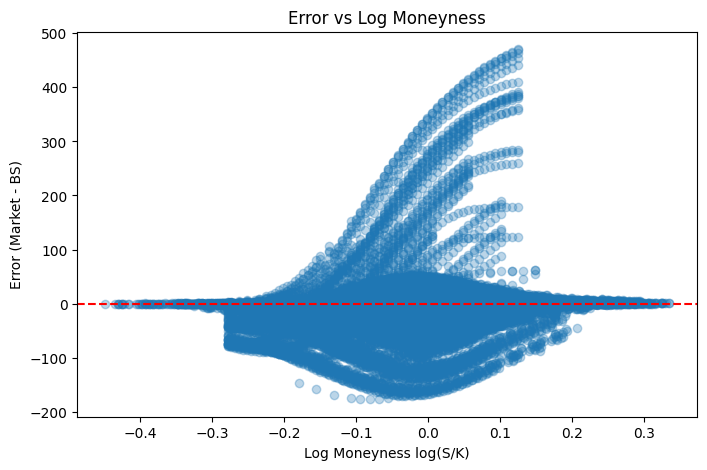

In [206]:
plt.figure(figsize=(8,5))

plt.scatter(df["log_moneyness"], df["error"], alpha=0.3)

plt.xlabel("Log Moneyness log(S/K)")
plt.ylabel("Error (Market - BS)")
plt.title("Error vs Log Moneyness")
plt.axhline(0, color='red', linestyle='--')
plt.show()

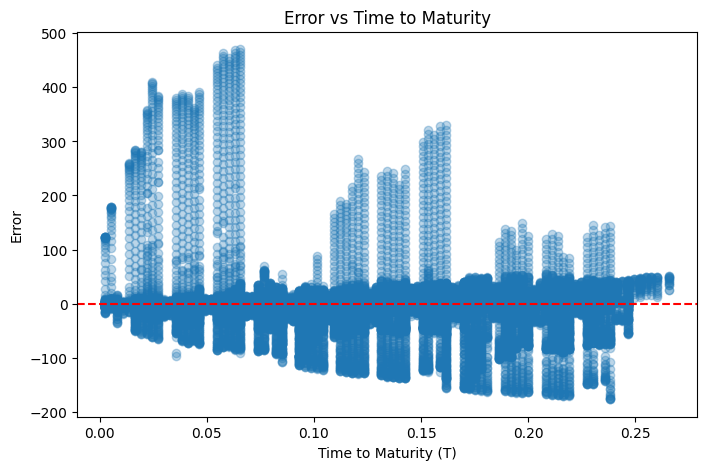

In [207]:
plt.figure(figsize=(8,5))

plt.scatter(df["T"], df["error"], alpha=0.3)

plt.xlabel("Time to Maturity (T)")
plt.ylabel("Error")
plt.title("Error vs Time to Maturity")
plt.axhline(0, color='red', linestyle='--')
plt.show()

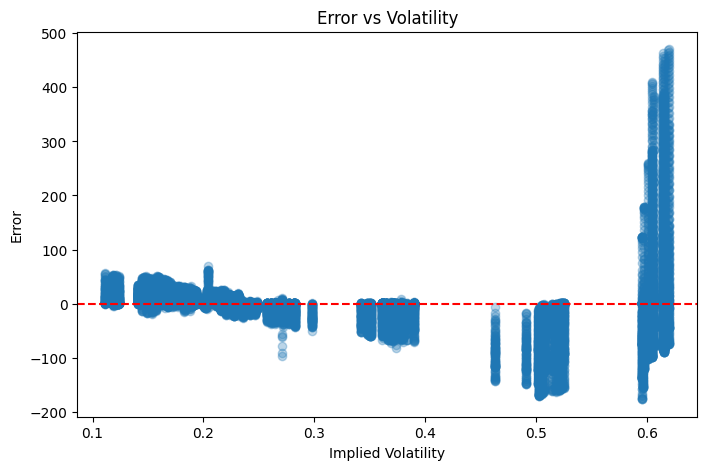

In [208]:
plt.figure(figsize=(8,5))

plt.scatter(df["sigma"], df["error"], alpha=0.3)

plt.xlabel("Implied Volatility")
plt.ylabel("Error")
plt.title("Error vs Volatility")
plt.axhline(0, color='red', linestyle='--')

plt.show()

In [209]:
df.head()

,Date,S,K,T,r,sigma,Market_Price,vix,vol_ma,bs_price,error,log_moneyness,sqrt_T,sigma_sqrt_T
17011,2024-01-01,2876.6,3340.0,0.161644,0.067,0.619995,158.60,10.8,623249.8,137.089149,21.510851,-0.149362,0.40205,0.249269
17012,2024-01-01,2876.6,3760.0,0.161644,0.067,0.619995,17.75,10.8,623249.8,62.862587,-45.112587,-0.267810,0.40205,0.249269
17013,2024-01-01,2876.6,3420.0,0.161644,0.067,0.619995,114.10,10.8,623249.8,118.776958,-4.676958,-0.173032,0.40205,0.249269
17014,2024-01-01,2876.6,3120.0,0.161644,0.067,0.619995,324.20,10.8,623249.8,200.451555,123.748445,-0.081224,0.40205,0.249269
17015,2024-01-01,2876.6,2840.0,0.161644,0.067,0.619995,587.55,10.8,623249.8,314.124304,273.425696,0.012805,0.40205,0.249269


### Model

In [ ]:
eps = 1e-6
split_date = "2025-05-01"

# GREEKS FUNCTION

def compute_greeks(df):
    S = df["S"].values
    K = df["K"].values
    T = df["T"].values
    r = df["r"].values
    sigma = df["sigma"].values

    sigma = np.maximum(sigma, eps)
    T = np.maximum(T, eps)

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    df["delta"] = norm.cdf(d1)
    df["gamma"] = norm.pdf(d1) / (S * sigma * np.sqrt(T) + eps)
    df["vega"] = S * norm.pdf(d1) * np.sqrt(T)
    df["theta"] = (
        - (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
        - r * K * np.exp(-r * T) * norm.cdf(d2)
    )

    return df

# PREPROCESS + FEATURE ENGINEERING
df = df.copy()

# Clean
df = df.replace([np.inf, -np.inf], np.nan)

# Filters (same as before)
df = df[(df["Market_Price"] > 5) & (df["bs_price"] > 5)]
df = df[(df["T"] > 0.05) & (df["T"] < 0.5)]
df = df[(df["log_moneyness"] > -0.3) & (df["log_moneyness"] < 0.3)]

# Greeks
df = compute_greeks(df)

# Relative features
df["vix_ratio"] = df["sigma"] / (df["vix"] + eps)
df["time_vol"] = df["sigma"] * np.sqrt(df["T"])


df["vega_scaled"] = df["vega"] / (df["Market_Price"] + 1e-6)
# Final cleanup
df = df.dropna()

# Sort
df = df.sort_values("Date").reset_index(drop=True)

# FEATURES LIST
features = [
    "log_moneyness", "T", "sqrt_T",
    "sigma", "sigma_sqrt_T", "vix", "vol_ma",
    "delta", "gamma", "vega", "theta",
    "vix_ratio", "time_vol","vega_scaled"
]

# TRAIN SPLIT
train_df = df[df["Date"] < split_date].copy()

# SCALING (FIT ONLY ON TRAIN)

scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[features])
X_full = scaler.transform(df[features])

y_train = train_df["Market_Price"].values
bs_train = train_df["bs_price"].values

bs_full = df["bs_price"].values

# TENSORS
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
bs_train = torch.tensor(bs_train, dtype=torch.float32)

X_full = torch.tensor(X_full, dtype=torch.float32)
bs_full = torch.tensor(bs_full, dtype=torch.float32)

# MODEL
# class HybridNet(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
        
#         self.shared = nn.Sequential(
#             nn.Linear(input_dim, 256),
#             nn.ReLU(),
#             nn.BatchNorm1d(256),

#             nn.Linear(256, 256),
#             nn.ReLU(),
#             nn.BatchNorm1d(256),

#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.BatchNorm1d(128),

#             nn.Linear(128, 128),
#             nn.ReLU(),

#             nn.Linear(128, 64),
#             nn.ReLU(),
#         )
        
#         self.log_error_head = nn.Linear(64, 1)
#         self.alpha_head = nn.Linear(64, 1)
        
#     def forward(self, x, bs):
#         h = self.shared(x)
        
#         log_error = self.log_error_head(h).squeeze()
#         alpha_raw = self.alpha_head(h).squeeze()
        
#         # same logic
#         alpha = torch.sigmoid(alpha_raw - 0.7 * log_error)
        
#         ml_price = bs * torch.exp(log_error)
#         hybrid = alpha * bs + (1 - alpha) * ml_price
        
#         return hybrid, alpha, log_error

class HybridNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),

            nn.Linear(128, 64),
            nn.ReLU(),
        )
        
        self.log_error_head = nn.Linear(64, 1)
        self.alpha_head = nn.Linear(64, 1)
        
    def forward(self, x, bs):
        h = self.shared(x)
        
        log_error = self.log_error_head(h).squeeze()

        log_error = torch.clamp(log_error, -2.5, 2.5)

        alpha_raw = self.alpha_head(h).squeeze()

        alpha = torch.sigmoid(alpha_raw - 0.3 * log_error)

        ml_price = bs * torch.exp(log_error)
        hybrid = alpha * bs + (1 - alpha) * ml_price

        return hybrid, alpha, log_error
# LOSS FUNCTION

def custom_loss(hybrid, market, alpha, log_error, bs,
                lambda_alpha=0.05,
                lambda_dir=0.15,
                lambda_ml=0.01):

    # Base error
    mse = torch.mean((hybrid - market) ** 2)
    
    # Reduce alpha randomness
    alpha_reg = torch.var(alpha)
    
    # Directional penalty
    gap = (market - bs) / (bs + 1e-6)
    error = hybrid - market

    dir_penalty = torch.mean(
        (gap > 0).float() * torch.relu(-error) * 2.5 +   
        (gap < 0).float() * torch.relu(error) * 2
    )
    
    # ML stability
    ml_reg = torch.mean(log_error ** 2)

    return mse + lambda_alpha * alpha_reg + lambda_dir * dir_penalty + lambda_ml * ml_reg

# TRAIN

model = HybridNet(input_dim=len(features))
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 1024

for epoch in range(epochs):
    model.train()
    
    perm = torch.randperm(X_train.size(0))
    total_loss = 0
    
    for i in range(0, X_train.size(0), batch_size):
        idx = perm[i:i+batch_size]
        
        xb = X_train[idx]
        yb = y_train[idx]
        bsb = bs_train[idx]
        
        optimizer.zero_grad()
        
        hybrid, alpha, log_error = model(xb, bsb)
        
        loss = custom_loss(hybrid, yb, alpha, log_error, bsb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss:.4f}")

# APPLY TO FULL DATA

model.eval()

with torch.no_grad():
    hybrid_pred, alpha_pred, log_error_pred = model(X_full, bs_full)

# Convert to numpy
hybrid_pred = hybrid_pred.detach().cpu().numpy().flatten()
alpha_pred = alpha_pred.detach().cpu().numpy().flatten()
log_error_pred = log_error_pred.detach().cpu().numpy().flatten()

bs_np = bs_full.detach().cpu().numpy()

ml_price = bs_np * np.exp(log_error_pred)

# SAVE RESULTS
df["ml_price"] = ml_price
df["alpha"] = alpha_pred
df["hybrid_price"] = hybrid_pred

# METRICS

y_full = df["Market_Price"].values

rmse_h = np.sqrt(np.mean((hybrid_pred - y_full) ** 2))
rmse_bs = np.sqrt(np.mean((bs_np - y_full) ** 2))

print(f"\nHybrid RMSE: {rmse_h:.4f}")
print(f"BS RMSE: {rmse_bs:.4f}")

Epoch 0 | Loss: 27043.6569
Epoch 5 | Loss: 1331.7280
Epoch 10 | Loss: 1232.2553
Epoch 15 | Loss: 721.0815
Epoch 20 | Loss: 799.4720
Epoch 25 | Loss: 566.5994
Epoch 30 | Loss: 477.0979
Epoch 35 | Loss: 740.5015
Epoch 40 | Loss: 442.1339
Epoch 45 | Loss: 485.8187

Hybrid RMSE: 5.9267
BS RMSE: 53.5021


### Comparison Plots and Analysis

In [213]:
# Errors
df["bs_error"] = df["Market_Price"] - df["bs_price"]
df["hybrid_error"] = df["Market_Price"] - df["hybrid_price"]

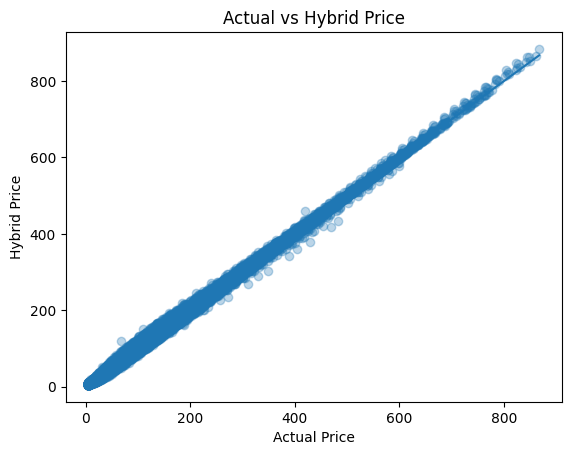

In [214]:
plt.figure()
plt.scatter(df["Market_Price"], df["hybrid_price"], alpha=0.3)

plt.plot([df["Market_Price"].min(), df["Market_Price"].max()],
         [df["Market_Price"].min(), df["Market_Price"].max()])

plt.xlabel("Actual Price")
plt.ylabel("Hybrid Price")
plt.title("Actual vs Hybrid Price")
plt.show()

In [176]:
## Improvement in handling both over and underpriced options; most points lie in the actual price line

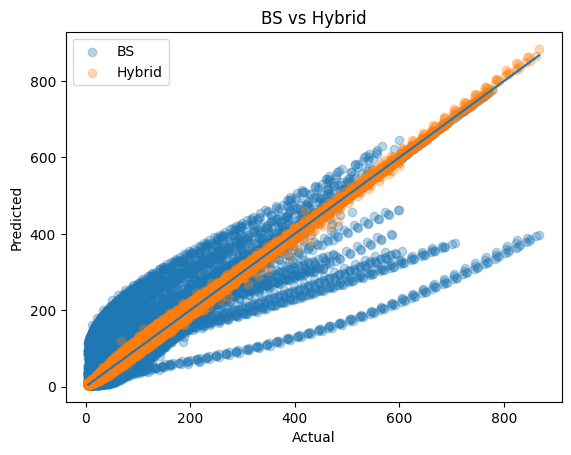

In [215]:
plt.figure()
plt.scatter(df["Market_Price"], df["bs_price"], alpha=0.3, label="BS")
plt.scatter(df["Market_Price"], df["hybrid_price"], alpha=0.3, label="Hybrid")

plt.plot([df["Market_Price"].min(), df["Market_Price"].max()],
         [df["Market_Price"].min(), df["Market_Price"].max()])

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("BS vs Hybrid")
plt.show()

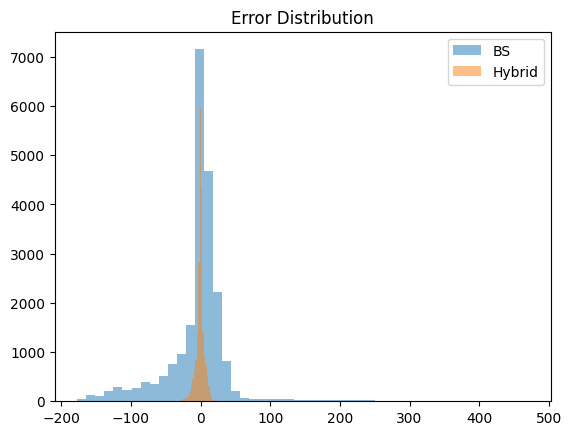

In [216]:
plt.figure()
plt.hist(df["bs_error"], bins=50, alpha=0.5, label="BS")
plt.hist(df["hybrid_error"], bins=50, alpha=0.5, label="Hybrid")

plt.legend()
plt.title("Error Distribution")
plt.show()

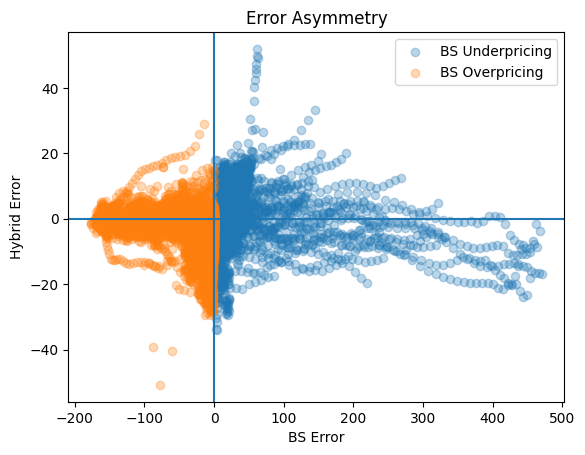

In [217]:
plt.figure()

pos_mask = df["bs_error"] > 0
neg_mask = df["bs_error"] < 0

plt.scatter(df["bs_error"][pos_mask], df["hybrid_error"][pos_mask],
            alpha=0.3, label="BS Underpricing")

plt.scatter(df["bs_error"][neg_mask], df["hybrid_error"][neg_mask],
            alpha=0.3, label="BS Overpricing")

plt.axhline(0)
plt.axvline(0)

plt.xlabel("BS Error")
plt.ylabel("Hybrid Error")
plt.legend()
plt.title("Error Asymmetry")
plt.show()

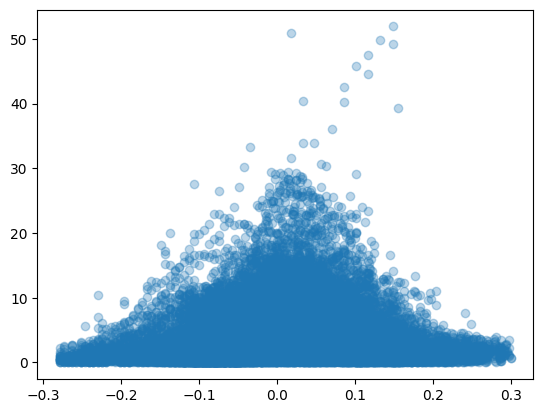

In [218]:
df["abs_error"] = abs(df["hybrid_price"] - df["Market_Price"])

plt.scatter(df["log_moneyness"], df["abs_error"], alpha=0.3)
plt.show()

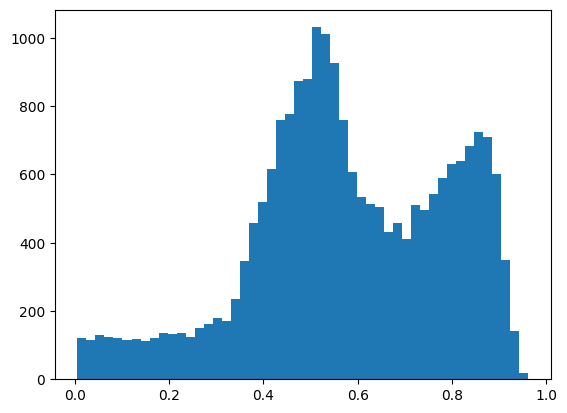

In [219]:
plt.hist(df["alpha"], bins=50)
plt.show()

In [220]:
print(np.mean(np.abs(df["hybrid_error"])) )
print(np.mean(np.abs(df["bs_error"])))

3.871315850469511
27.643809708482802


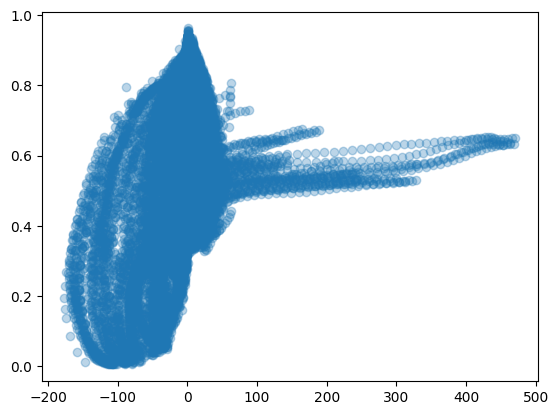

In [221]:
plt.scatter(df["bs_error"], df["alpha"], alpha=0.3)
plt.show()

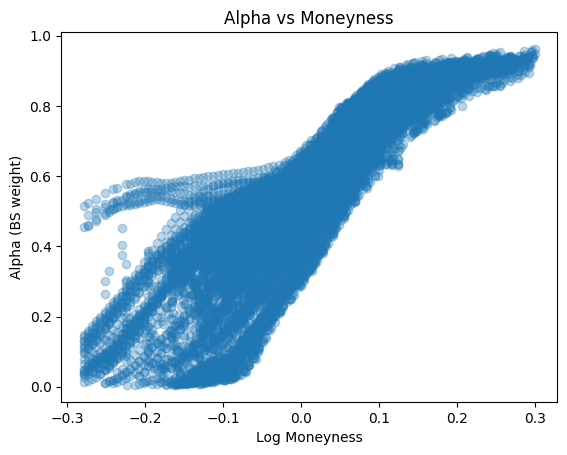

In [222]:
plt.figure()
plt.scatter(df["log_moneyness"], df["alpha"], alpha=0.3)

plt.xlabel("Log Moneyness")
plt.ylabel("Alpha (BS weight)")
plt.title("Alpha vs Moneyness")
plt.show()

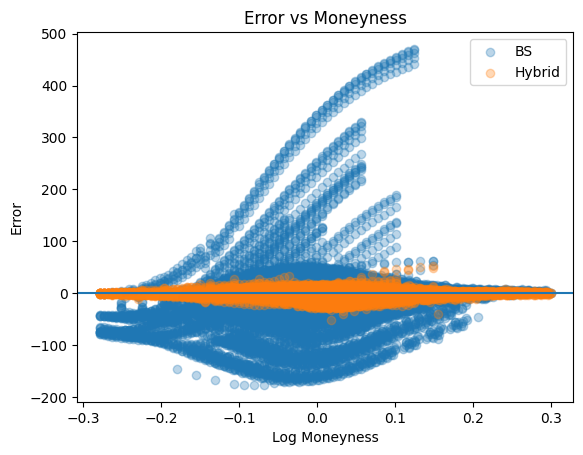

In [223]:
plt.figure()
plt.scatter(df["log_moneyness"], df["bs_error"], alpha=0.3, label="BS")
plt.scatter(df["log_moneyness"], df["hybrid_error"], alpha=0.3, label="Hybrid")

plt.axhline(0)
plt.xlabel("Log Moneyness")
plt.ylabel("Error")
plt.legend()
plt.title("Error vs Moneyness")
plt.show()

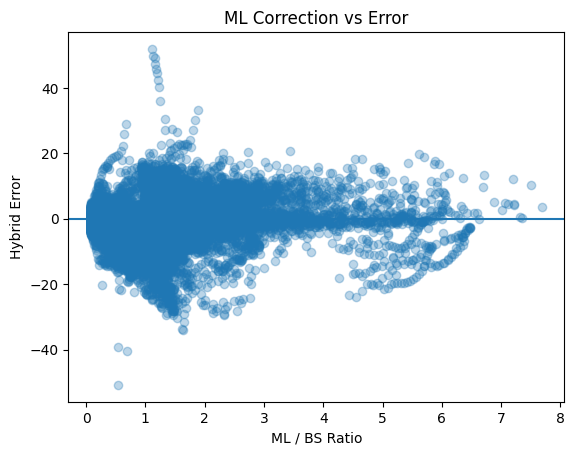

In [224]:
correction = df["ml_price"] / df["bs_price"]

plt.figure()
plt.scatter(correction, df["hybrid_error"], alpha=0.3)

plt.axhline(0)
plt.xlabel("ML / BS Ratio")
plt.ylabel("Hybrid Error")
plt.title("ML Correction vs Error")
plt.show()

In [225]:

def stress_test_compare(model, df, feature_cols, scaler):
    import numpy as np
    import torch

    model.eval()
    results = {}

    scenarios = {
        "base": df.copy(),
        "low_vol": df.assign(sigma=df["sigma"] * 0.5),
        "high_vol": df.assign(sigma=df["sigma"] * 2),
        "deep_ITM": df.assign(K=df["K"] * 0.7),
        "deep_OTM": df.assign(K=df["K"] * 1.3),
        "near_expiry": df.assign(T=np.maximum(df["T"] * 0.1, 1e-4)),
    }

    for name, df_s in scenarios.items():
        df_s = df_s.copy()

        df_s = recompute_features(df_s)
        
        S = df_s["S"].values
        K = df_s["K"].values
        T = df_s["T"].values
        r = df_s["r"].values
        sigma = df_s["sigma"].values

        from scipy.stats import norm
        import numpy as np

        d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
        d2 = d1 - sigma*np.sqrt(T)

        bs_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)

        # model input
        X = scaler.transform(df_s[feature_cols])
        X = torch.tensor(X, dtype=torch.float32)
        bs_tensor = torch.tensor(bs_price, dtype=torch.float32)

        with torch.no_grad():
            hybrid, _, _ = model(X, bs_tensor)

        hybrid_np = hybrid.detach().cpu().numpy()

        results[name] = {
            "hybrid_mean": np.mean(hybrid_np),
            "hybrid_std": np.std(hybrid_np),
            "bs_mean": np.mean(bs_price),
            "bs_std": np.std(bs_price),
        }

    return results

def recompute_features(df):
    eps = 1e-6

    # basic
    df["sqrt_T"] = np.sqrt(df["T"])
    df["sigma_sqrt_T"] = df["sigma"] * df["sqrt_T"]

    # log moneyness
    df["log_moneyness"] = np.log(df["S"] / df["K"])

    # Greeks
    df = compute_greeks(df)

    # derived
    df["vix_ratio"] = df["sigma"] / (df["vix"] + eps)
    df["time_vol"] = df["sigma"] * np.sqrt(df["T"])
    df["vega_scaled"] = df["vega"] / (df["Market_Price"] + eps)

    return df



In [226]:
results = stress_test_compare(model, df, features, scaler)

In [227]:
pd.DataFrame(results)

,base,low_vol,high_vol,deep_ITM,deep_OTM,near_expiry
hybrid_mean,167.961960,147.807129,253.242188,803.621033,12.422490,131.742340
hybrid_std,149.453384,145.003586,226.697205,185.168961,22.605406,148.045120
bs_mean,169.784882,135.841223,258.803039,799.148590,9.995208,117.138340
bs_std,140.311637,146.444790,158.223875,173.738378,22.773379,143.840916


In [190]:
# Stable in base, ITM, and OTM regimes, closely aligned with Black-Scholes.
# Slightly less sensitive in low volatility, maintaining higher prices.
# Overreacts under high volatility, showing large variance and instability.
# Near expiry behavior is reasonable with mild variance increase.

# Overall: stable in normal conditions, but needs control under extreme volatility.

In [230]:
def get_predictions(model, df, features, scaler):

    model.eval()
    df = recompute_features(df.copy())

    # scale
    X = scaler.transform(df[features])
    X = torch.tensor(X, dtype=torch.float32)

    # ✅ vectorize your scalar BS function
    bs_vec = np.vectorize(bs_call)

    bs_price = bs_vec(
        df["S"].values,
        df["K"].values,
        df["T"].values,
        df["r"].values,
        df["sigma"].values,
        0.01
    )

    bs_tensor = torch.tensor(bs_price, dtype=torch.float32)

    with torch.no_grad():
        hybrid, _, _ = model(X, bs_tensor)

    hybrid = hybrid.detach().cpu().numpy()

    return hybrid, bs_price

def stress_scenarios(model, df, features, scaler):
    scenarios = {
        "base": df.copy(),

        "low_vol": df.assign(sigma=df["sigma"] * 0.5),
        "high_vol": df.assign(sigma=df["sigma"] * 2),

        "deep_ITM": df.assign(K=df["K"] * 0.7),
        "deep_OTM": df.assign(K=df["K"] * 1.3),

        "near_expiry": df.assign(T=np.maximum(df["T"] * 0.1, 1e-4)),

        "market_crash": df.assign(
            sigma=df["sigma"] * 2,
            S=df["S"] * 0.8,
            T=np.maximum(df["T"] * 0.5, 1e-4)
        )
    }

    results = {}

    for name, df_s in scenarios.items():
        hybrid, bs = get_predictions(model, df_s, features, scaler)

        results[name] = {
            "hybrid_mean": np.mean(hybrid),
            "hybrid_std": np.std(hybrid),
            "bs_mean": np.mean(bs),
            "bs_std": np.std(bs)
        }

    return results


def regime_test(model, df, features, scaler):
    median_vix = df["vix"].median()

    low_regime = df[df["vix"] < median_vix]
    high_regime = df[df["vix"] >= median_vix]

    results = {}

    for name, subset in [("low_vix", low_regime), ("high_vix", high_regime)]:
        hybrid, bs = get_predictions(model, subset, features, scaler)

        market = subset["Market_Price"].values

        rmse_h = np.sqrt(np.mean((hybrid - market)**2))
        rmse_bs = np.sqrt(np.mean((bs - market)**2))

        results[name] = {
            "hybrid_rmse": rmse_h,
            "bs_rmse": rmse_bs
        }

    return results

def tail_risk_analysis(model, df, features, scaler):
    hybrid, bs = get_predictions(model, df, features, scaler)
    market = df["Market_Price"].values

    # relative error
    hybrid_err = (hybrid - market) / (market + 1e-6)
    bs_err = (bs - market) / (market + 1e-6)

    results = {
        "hybrid_95": np.percentile(np.abs(hybrid_err), 95),
        "hybrid_99": np.percentile(np.abs(hybrid_err), 99),
        "bs_95": np.percentile(np.abs(bs_err), 95),
        "bs_99": np.percentile(np.abs(bs_err), 99),
    }

    return results

In [231]:
# Scenario stress
scenario_results = stress_scenarios(model, df, features, scaler)

# Regime testing
regime_results = regime_test(model, df, features, scaler)

# Tail risk
tail_results = tail_risk_analysis(model, df, features, scaler)

In [233]:
df_scen = pd.DataFrame(scenario_results).T

df_scen["mean_diff"] = df_scen["hybrid_mean"] - df_scen["bs_mean"]
df_scen["std_diff"]  = df_scen["hybrid_std"]  - df_scen["bs_std"]
pd.DataFrame(df_scen)

,hybrid_mean,hybrid_std,bs_mean,bs_std,mean_diff,std_diff
base,165.866653,148.520294,167.729057,139.420902,-1.862404,9.099392
low_vol,145.310730,144.088959,133.856211,145.363527,11.454519,-1.274568
high_vol,251.391312,225.698944,256.699060,157.564592,-5.307748,68.134352
deep_ITM,800.128906,184.974762,795.672104,173.695021,4.456802,11.279741
deep_OTM,12.090471,22.078402,9.790837,22.392730,2.299635,-0.314329
near_expiry,131.508453,147.921738,116.954104,143.725986,14.554349,4.195751
market_crash,41.136684,66.411980,27.207486,43.207640,13.929199,23.204340


In [194]:
# Base: Hybrid aligns with BS; slightly higher variance.
# Low vol: Hybrid less sensitive to volatility drop; maintains higher prices.
# High vol: Strong overreaction... large mean and very high variance (instability).
# Deep ITM/OTM: Stable and close to BS; no spurious pricing.
# Near expiry: Slight premium uplift with moderate variance increase.
# Market crash: Hybrid prices higher than BS with elevated variance, indicating sensitivity to joint shocks.

# Overall: Stable across most regimes, but needs tighter control under extreme volatility and crash

In [234]:
df_reg = pd.DataFrame(regime_results).T

df_reg["rmse_diff"] = df_reg["hybrid_rmse"] - df_reg["bs_rmse"]

print("\nRegime Comparison:\n")
print(df_reg)


Regime Comparison:

          hybrid_rmse    bs_rmse  rmse_diff
low_vix      6.803472  53.009400 -46.205929
high_vix     4.902081  53.987452 -49.085371


In [235]:
tail_df = pd.DataFrame([tail_results])

tail_df["diff_95"] = tail_df["hybrid_95"] - tail_df["bs_95"]
tail_df["diff_99"] = tail_df["hybrid_99"] - tail_df["bs_99"]

print("\nTail Risk Comparison:\n")
print(tail_df)


Tail Risk Comparison:

   hybrid_95  hybrid_99     bs_95     bs_99   diff_95   diff_99
0   0.201298   0.354178  2.555977  7.833645 -2.354679 -7.479467
